In [44]:
# Import Libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

In [45]:
# Connect to SQLite database
conn = sqlite3.connect("../data/sales.db")

## SQL Queries for Business Analysis

In [46]:
# Sales by Region
query = """
SELECT region, SUM(sales) AS total_sales
FROM sales_data
GROUP BY region
ORDER BY total_sales DESC
"""
sales_by_region = pd.read_sql(query, conn)

In [47]:
# Sales by Category
query = """
SELECT category, SUM(sales) AS total_sales
FROM sales_data
GROUP BY category
ORDER BY total_sales DESC
"""
sales_by_category = pd.read_sql(query, conn)

In [48]:
# Top 10 Best Selling Products
query = """
SELECT product_name, SUM(sales) AS revenue
FROM sales_data
GROUP BY product_name
ORDER BY revenue DESC
LIMIT 10
"""
top_products = pd.read_sql(query, conn)

In [49]:
# Top 10 Customers
query = """
SELECT customer_name, SUM(sales) AS total_spent
FROM sales_data
GROUP BY customer_name
ORDER BY total_spent DESC
LIMIT 10
"""
top_customers = pd.read_sql(query, conn)

In [50]:
# Monthly Sales Trend
query = """
SELECT 
    order_year || '-' || order_month AS month,
    SUM(sales) AS monthly_sales
FROM sales_data
GROUP BY month
ORDER BY month
"""
monthly_sales = pd.read_sql(query, conn)

In [51]:
# Profit Margin by Category
query = """
    SELECT category,
           ROUND((SUM(profit) * 100.0 / SUM(sales)), 2) AS profit_margin_percent
    FROM sales_data
    GROUP BY category
    ORDER BY profit_margin_percent DESC
"""
profit_margin = pd.read_sql(query, conn)

In [52]:
# Sales by Customer Segment
query = """
    SELECT segment, SUM(sales) AS total_sales
    FROM sales_data
    GROUP BY segment
    ORDER BY total_sales DESC
"""
sales_by_segment = pd.read_sql(query, conn)

## Data Visualization

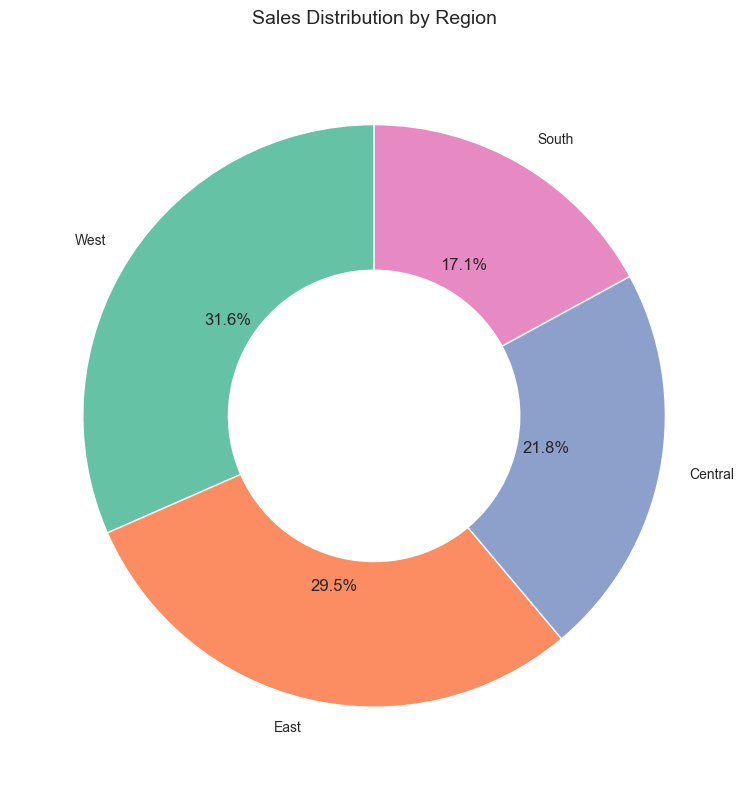

In [53]:
# 1. Sales by Region
fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette('Set2', len(sales_by_region))
wedges, texts, autotexts = ax.pie(
    sales_by_region['total_sales'],
    labels=sales_by_region['region'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5)
)
for text in autotexts:
    text.set_fontsize(12)
ax.set_title('Sales Distribution by Region', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../images/sales_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

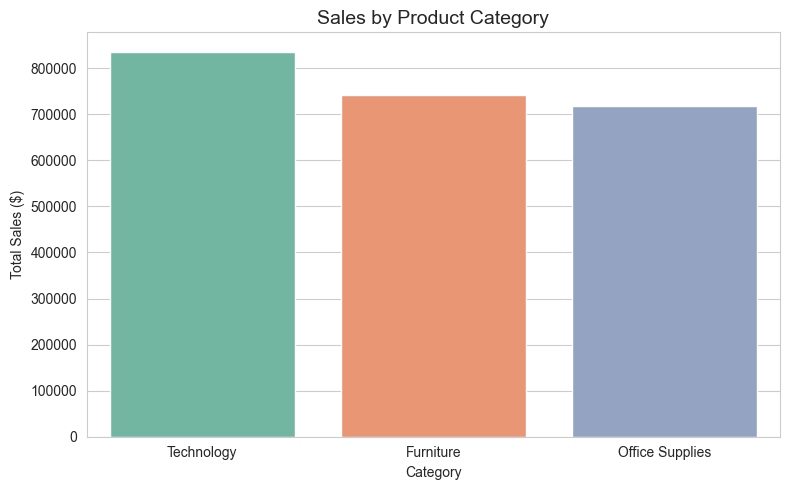

In [54]:
# 2. Sales by Category
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_category, x='category', y='total_sales',
            hue='category', palette='Set2', legend=False)
plt.title('Sales by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../images/sales_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

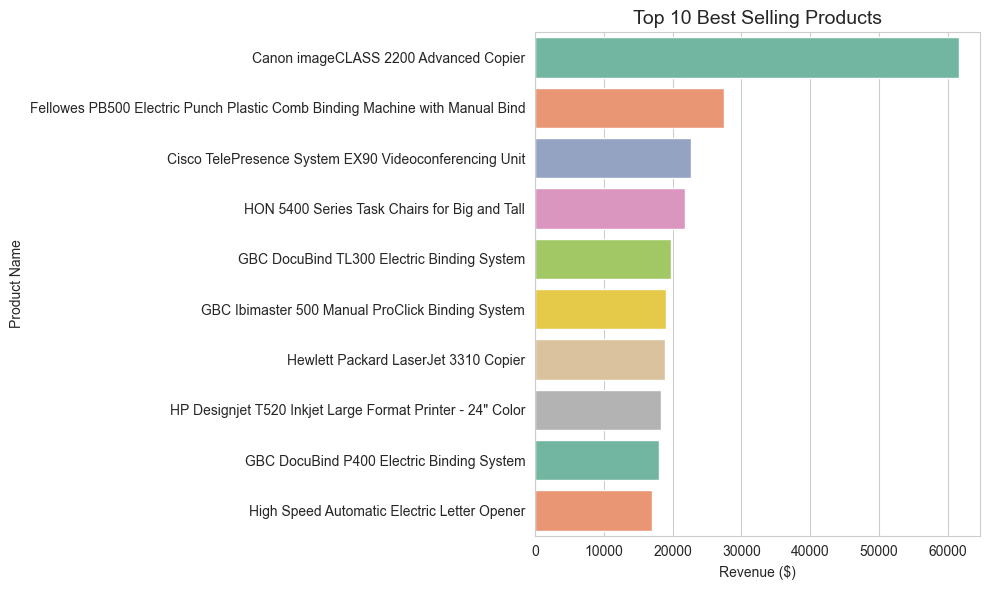

In [55]:
# 3. Top 10 Best Selling Products
plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, y='product_name', x='revenue',
            hue='product_name', palette='Set2', legend=False)
plt.title('Top 10 Best Selling Products', fontsize=14)
plt.xlabel('Revenue ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('../images/top_products.png', dpi=300, bbox_inches='tight')
plt.show()

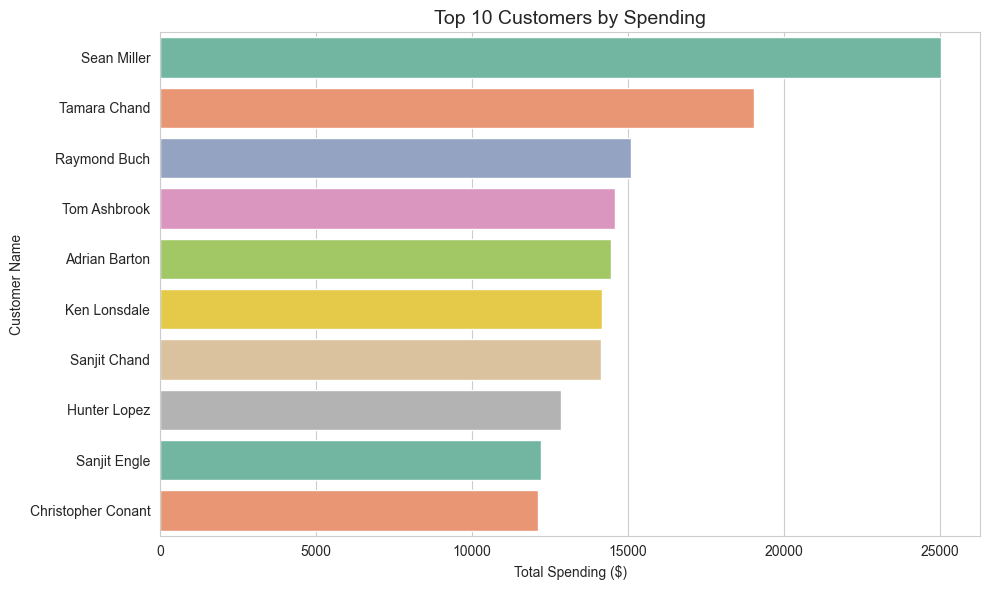

In [56]:
# 4. Top 10 Customers by Spending
plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers, y='customer_name', x='total_spent',
            hue='customer_name', palette='Set2', legend=False)
plt.title('Top 10 Customers by Spending', fontsize=14)
plt.xlabel('Total Spending ($)')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.savefig('../images/top_customers.png', dpi=300, bbox_inches='tight')
plt.show()

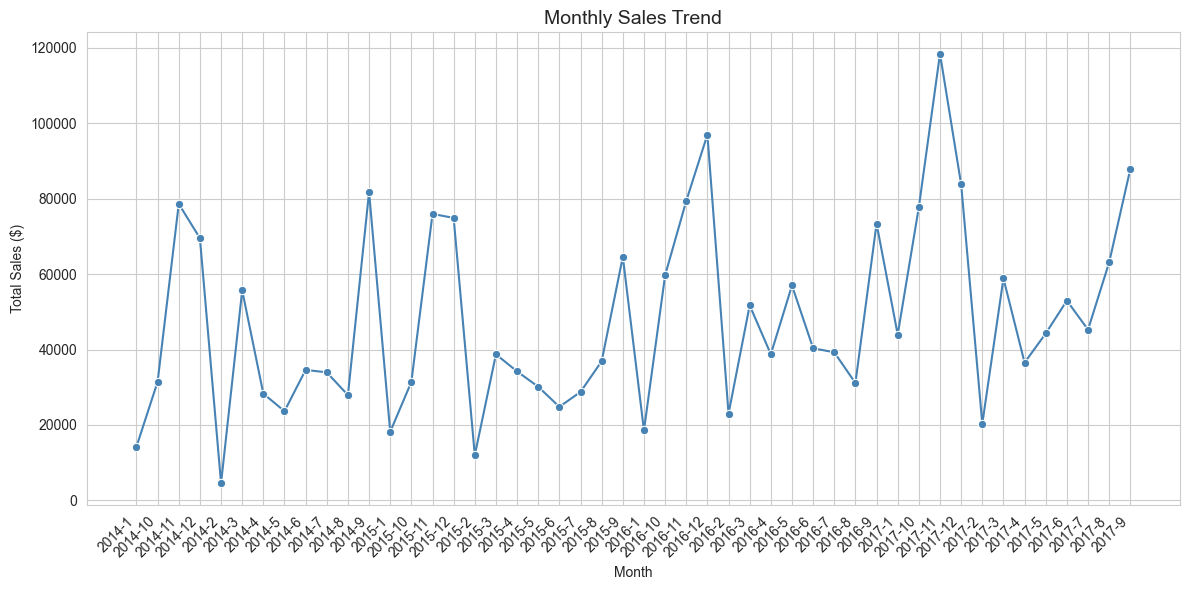

In [57]:
# 5. Monthly Sales Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='month', y='monthly_sales', marker='o', color='steelblue')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

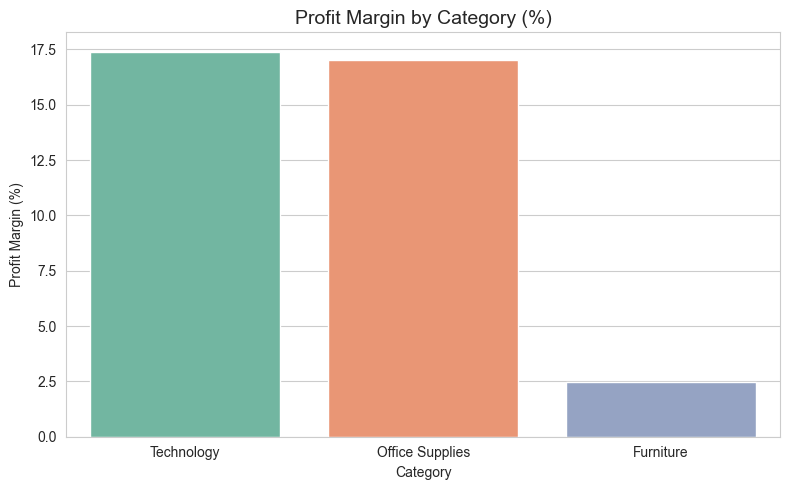

In [58]:
# 6. Profit Margin by Category
plt.figure(figsize=(8, 5))
sns.barplot(data=profit_margin, x='category', y='profit_margin_percent',
            hue='category', palette='Set2', legend=False)
plt.title('Profit Margin by Category (%)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.savefig('../images/profit_margin_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

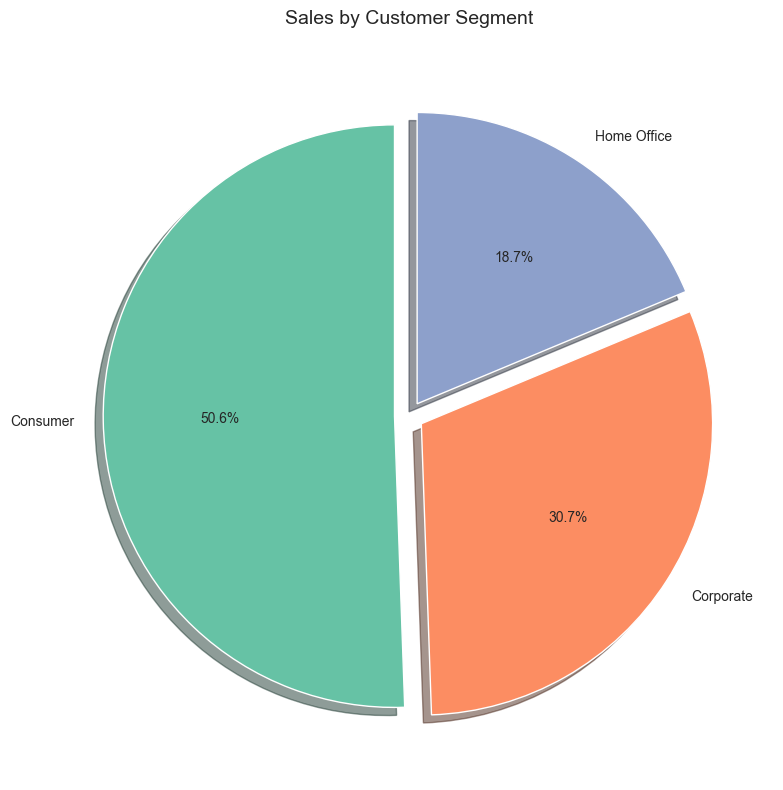

In [59]:
# 7. Sales by Customer Segment
fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette("Set2", len(sales_by_segment))
ax.pie(
    sales_by_segment["total_sales"],
    labels=sales_by_segment["segment"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=[0.05] * len(sales_by_segment),
    shadow=True
)
ax.set_title("Sales by Customer Segment", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("../images/sales_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

Key Business Insights

In [60]:
# Key Business Insights directly from data
total_orders = pd.read_sql('SELECT COUNT(DISTINCT order_id) AS total FROM sales_data', conn).iloc[0, 0]
total_revenue = pd.read_sql('SELECT ROUND(SUM(sales), 2) AS total FROM sales_data', conn).iloc[0, 0]
total_profit = pd.read_sql('SELECT ROUND(SUM(profit), 2) AS total FROM sales_data', conn).iloc[0, 0]
top_region = sales_by_region.iloc[0]['region']
top_category = sales_by_category.iloc[0]['category']
top_product = top_products.iloc[0]['product_name']
top_customer = top_customers.iloc[0]['customer_name']

print('=' * 55)
print('         KEY BUSINESS INSIGHTS')
print('=' * 55)
print(f'Total Orders       : {total_orders:,}')
print(f'Total Revenue      : ${total_revenue:,.2f}')
print(f'Total Profit       : ${total_profit:,.2f}')
print(f'Top Region         : {top_region}')
print(f'Top Category       : {top_category}')
print(f'Top Product        : {top_product}')
print(f'Top Customer       : {top_customer}')
print('=' * 55)

         KEY BUSINESS INSIGHTS
Total Orders       : 5,009
Total Revenue      : $2,297,200.86
Total Profit       : $286,397.02
Top Region         : West
Top Category       : Technology
Top Product        : Canon imageCLASS 2200 Advanced Copier
Top Customer       : Sean Miller


In [61]:
# Close database connection
conn.close()
print('Database connection closed.')

Database connection closed.
